In [2]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные
df = pd.read_csv('articles.csv')
print(f"Размер исходного датафрейма: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
df.head()

Размер исходного датафрейма: (105542, 25)
Колонки: ['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [2]:
# Удаляем строки с пропусками в выбранных колонках
df_filtered = df.dropna(subset=['prod_name', 'detail_desc', 'garment_group_name'])
print(f"Размер после удаления пропусков: {df_filtered.shape}")

# Выбираем 5 самых частых групп
top_5_groups = df_filtered['garment_group_name'].value_counts().head(5).index.tolist()
print(f"5 самых частых групп: {top_5_groups}")

# Оставляем только товары из этих групп
df_top_groups = df_filtered[df_filtered['garment_group_name'].isin(top_5_groups)]

# Ограничиваем выборку до 10,000 записей
df_top_groups = df_top_groups.sample(frac=1, random_state=42).reset_index(drop=True)
df_final = df_top_groups.iloc[:10000]

print(f"Финальный размер датафрейма: {df_final.shape}")
print(f"Распределение групп:\n{df_final['garment_group_name'].value_counts()}")

Размер после удаления пропусков: (105126, 25)
5 самых частых групп: ['Jersey Fancy', 'Accessories', 'Jersey Basic', 'Knitwear', 'Under-, Nightwear']
Финальный размер датафрейма: (10000, 25)
Распределение групп:
garment_group_name
Jersey Fancy         3840
Accessories          2047
Jersey Basic         1470
Knitwear             1329
Under-, Nightwear    1314
Name: count, dtype: int64


Пропуски в финальном датафрейме:
article_id                      0
product_code                    0
prod_name                       0
product_type_no                 0
product_type_name               0
product_group_name              0
graphical_appearance_no         0
graphical_appearance_name       0
colour_group_code               0
colour_group_name               0
perceived_colour_value_id       0
perceived_colour_value_name     0
perceived_colour_master_id      0
perceived_colour_master_name    0
department_no                   0
department_name                 0
index_code                      0
index_name                      0
index_group_no                  0
index_group_name                0
section_no                      0
section_name                    0
garment_group_no                0
garment_group_name              0
detail_desc                     0
dtype: int64


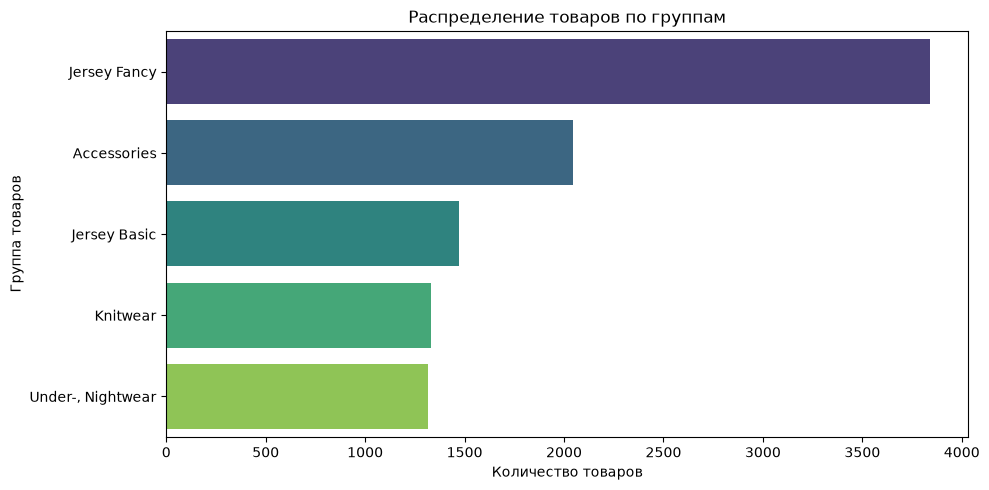

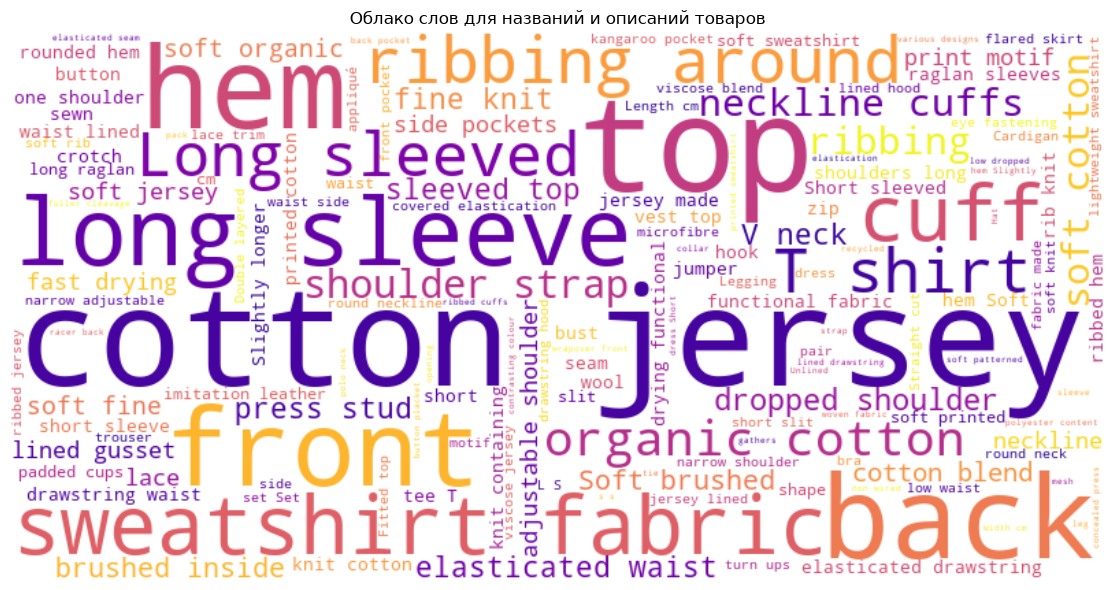

In [3]:
# Проверка пропусков
print("Пропуски в финальном датафрейме:")
print(df_final.isnull().sum())

# Визуализация 1: Распределение классов
plt.figure(figsize=(10, 5))
sns.countplot(data=df_final, y='garment_group_name', 
              order=df_final['garment_group_name'].value_counts().index, 
              palette='viridis')
plt.title('Распределение товаров по группам')
plt.xlabel('Количество товаров')
plt.ylabel('Группа товаров')
plt.tight_layout()
plt.show()

# Визуализация 2: Облако слов для объединенных текстов
from wordcloud import WordCloud

# Создаем текстовый признак
df_final['text'] = df_final['prod_name'] + " " + df_final['detail_desc']

# Объединяем все тексты в одну большую строку
all_text = " ".join(df_final['text'])

# Создаем облако слов
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='plasma', max_words=150).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов для названий и описаний товаров')
plt.tight_layout()
plt.show()

In [4]:
X = df_final['text']
y = df_final['garment_group_name']

# Кодируем метки
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Разделяем данные (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print("Метки классов:", le.classes_)

Размер обучающей выборки: 8000
Размер тестовой выборки: 2000
Метки классов: ['Accessories' 'Jersey Basic' 'Jersey Fancy' 'Knitwear'
 'Under-, Nightwear']


In [6]:
# 5.1 DummyClassifier
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Результаты DummyClassifier:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(classification_report(y_test, y_pred_dummy, target_names=le.classes_))

# 5.2 TF-IDF + LogisticRegression
tfidf = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

print("\nРезультаты TF-IDF + LogisticRegression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Сохраняем результаты для сравнения
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')

Результаты DummyClassifier:
Accuracy: 0.3840
                   precision    recall  f1-score   support

      Accessories       0.00      0.00      0.00       409
     Jersey Basic       0.00      0.00      0.00       294
     Jersey Fancy       0.38      1.00      0.55       768
         Knitwear       0.00      0.00      0.00       266
Under-, Nightwear       0.00      0.00      0.00       263

         accuracy                           0.38      2000
        macro avg       0.08      0.20      0.11      2000
     weighted avg       0.15      0.38      0.21      2000


Результаты TF-IDF + LogisticRegression:
Accuracy: 0.9295
                   precision    recall  f1-score   support

      Accessories       0.99      0.99      0.99       409
     Jersey Basic       0.94      0.76      0.84       294
     Jersey Fancy       0.88      0.96      0.92       768
         Knitwear       0.95      0.94      0.94       266
Under-, Nightwear       0.98      0.93      0.95       263

       

In [ ]:
# Установка PyTorch
!pip install torch torchvision

# Проверка установки
import torch
print(f"PyTorch версия: {torch.__version__}")

   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 1.3/124.1 MB 5.8 MB/s eta 0:00:22
   - -------------------------------------- 5.8/124.1 MB 14.2 MB/s eta 0:00:09
   ----- ---------------------------------- 16.5/124.1 MB 27.6 MB/s eta 0:00:04
   --------- ------------------------------ 29.1/124.1 MB 36.4 MB/s eta 0:00:03
   ------------ --------------------------- 37.5/124.1 MB 37.3 MB/s eta 0:00:03
   -------------- ------------------------- 45.4/124.1 MB 37.7 MB/s eta 0:00:03
   ---------------- ----------------------- 49.8/124.1 MB 35.6 MB/s eta 0:00:03
   ----------------- ---------------------- 53.2/124.1 MB 33.3 MB/s eta 0:00:03
   ----------------- ---------------------- 55.6/124.1 MB 30.9 MB/s eta 0:00:03
   ------------------ --------------------- 58.2/124.1 MB 28.8 MB/s eta 0:00:03
   ------------------- -------------------- 60.6/124.1 MB 27.

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

def build_vocab(texts, vocab_size=5000):
    counter = Counter()
    for text in texts:
        tokens = re.findall(r'\b[a-zA-Z]+\b', text.lower())
        counter.update(tokens)
    
    vocab = {word: i+2 for i, (word, _) in enumerate(counter.most_common(vocab_size-2))}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab

def text_to_sequence(text, vocab, max_len=50):
    tokens = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    seq = [vocab.get(token, vocab['<UNK>']) for token in tokens[:max_len]]
    seq += [vocab['<PAD>']] * (max_len - len(seq))
    return seq

# Строим словарь
vocab = build_vocab(X_train, vocab_size=10000)
vocab_size = len(vocab)
max_len = 50

# Преобразуем тексты в последовательности
X_train_seq = np.array([text_to_sequence(text, vocab, max_len) for text in X_train])
X_test_seq = np.array([text_to_sequence(text, vocab, max_len) for text in X_test])

print(f"Форма X_train_seq: {X_train_seq.shape}")
print(f"Форма X_test_seq: {X_test_seq.shape}")

# Создаем Dataset и DataLoader
class TextDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

batch_size = 64
train_dataset = TextDataset(X_train_seq, y_train)
test_dataset = TextDataset(X_test_seq, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Форма X_train_seq: (8000, 50)
Форма X_test_seq: (2000, 50)


In [8]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers=1, dropout=0.5):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, n_layers, batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        last_hidden = hidden[-1]
        dropped = self.dropout(last_hidden)
        output = self.fc(dropped)
        return output

# Параметры модели
EMBED_DIM = 128
HIDDEN_DIM = 64
OUTPUT_DIM = len(le.classes_)
N_LAYERS = 2
DROPOUT = 0.5

model = LSTMModel(vocab_size, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Модель LSTM на устройстве: {device}")
print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")

Модель LSTM на устройстве: cpu
Количество параметров: 692,677


In [9]:
def train_model(model, train_loader, test_loader, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    test_losses = []
    test_accuracies = []
    
    for epoch in range(epochs):
        # Обучение
        model.train()
        epoch_loss = 0
        for sequences, labels in train_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            
            optimizer.zero_grad()
            predictions = model(sequences)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Валидация
        model.eval()
        test_loss = 0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for sequences, labels in test_loader:
                sequences, labels = sequences.to(device), labels.to(device)
                predictions = model(sequences)
                loss = criterion(predictions, labels)
                test_loss += loss.item()
                
                _, preds = torch.max(predictions, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)
        
        accuracy = accuracy_score(all_labels, all_preds)
        test_accuracies.append(accuracy)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Test Acc: {accuracy:.4f}")
    
    return train_losses, test_losses, test_accuracies, all_preds

print("\nНачинаем обучение LSTM...")
train_losses, test_losses, test_accuracies, y_pred_lstm = train_model(
    model, train_loader, test_loader, epochs=10, lr=0.001
)


Начинаем обучение LSTM...
Epoch 1/10 | Train Loss: 1.5183 | Test Loss: 1.4983 | Test Acc: 0.3840
Epoch 2/10 | Train Loss: 1.3238 | Test Loss: 1.0110 | Test Acc: 0.5955
Epoch 3/10 | Train Loss: 0.8702 | Test Loss: 0.7531 | Test Acc: 0.7070
Epoch 4/10 | Train Loss: 0.7229 | Test Loss: 0.6556 | Test Acc: 0.7590
Epoch 5/10 | Train Loss: 0.6122 | Test Loss: 0.5559 | Test Acc: 0.7785
Epoch 6/10 | Train Loss: 0.5135 | Test Loss: 0.4562 | Test Acc: 0.8400
Epoch 7/10 | Train Loss: 0.4283 | Test Loss: 0.4717 | Test Acc: 0.8510
Epoch 8/10 | Train Loss: 0.3818 | Test Loss: 0.3677 | Test Acc: 0.8825
Epoch 9/10 | Train Loss: 0.2959 | Test Loss: 0.3507 | Test Acc: 0.8930
Epoch 10/10 | Train Loss: 0.2786 | Test Loss: 0.3548 | Test Acc: 0.8950



РЕЗУЛЬТАТЫ LSTM МОДЕЛИ
Accuracy: 0.8950
Macro-F1: 0.8895

Classification Report:
                   precision    recall  f1-score   support

      Accessories       0.99      0.91      0.95       409
     Jersey Basic       0.82      0.79      0.81       294
     Jersey Fancy       0.89      0.91      0.90       768
         Knitwear       0.88      0.94      0.91       266
Under-, Nightwear       0.88      0.89      0.88       263

         accuracy                           0.90      2000
        macro avg       0.89      0.89      0.89      2000
     weighted avg       0.90      0.90      0.90      2000



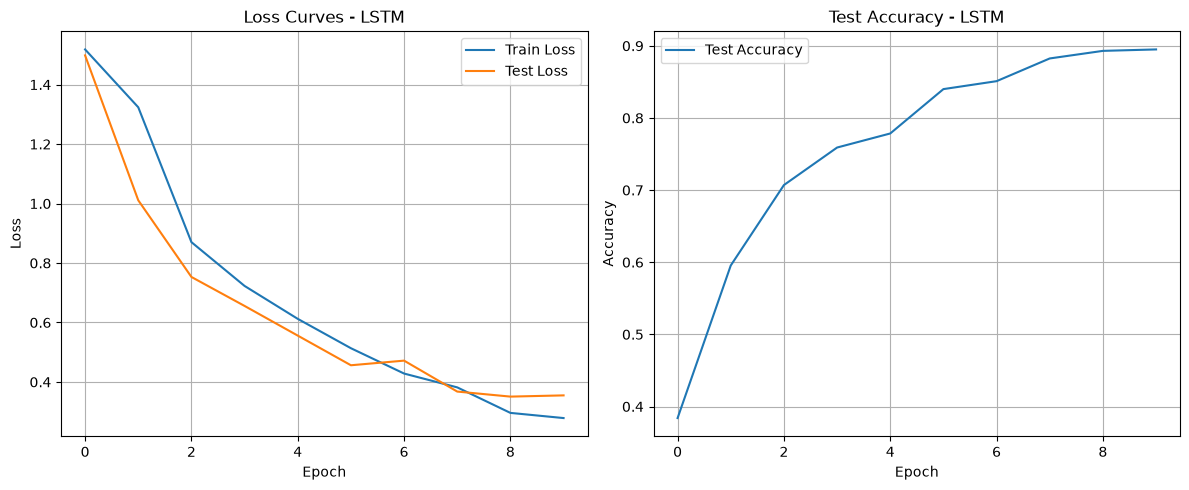

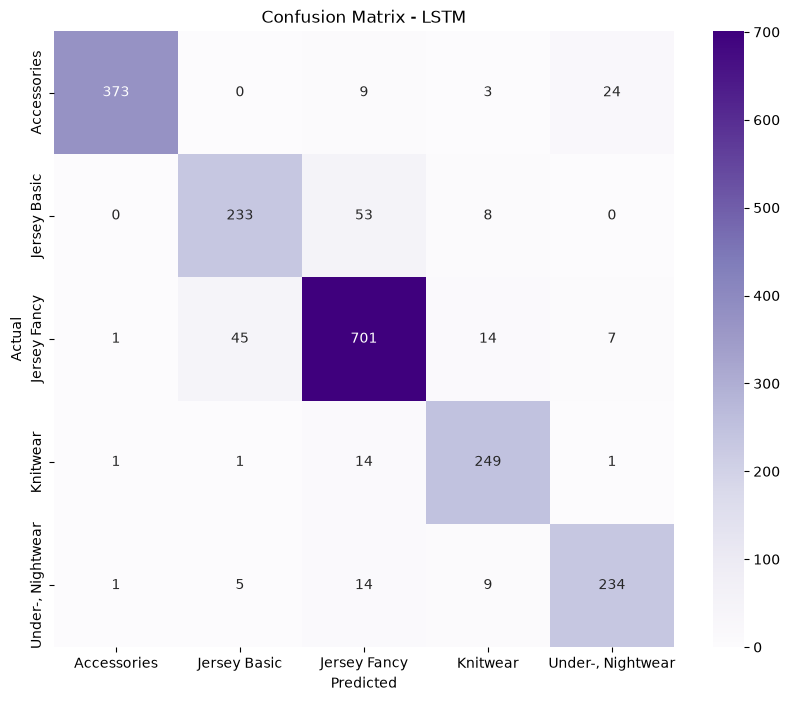


СРАВНЕНИЕ МОДЕЛЕЙ (LR vs LSTM)
Logistic Regression:
  - Accuracy: 0.9295
  - Macro-F1: 0.9274

LSTM:
  - Accuracy: 0.8950
  - Macro-F1: 0.8895

ℹ️ Logistic Regression лучше или сопоставима с LSTM

ТОП-3 ОШИБОЧНЫХ ПРЕДСКАЗАНИЙ LSTM

Ошибка #1:
Текст: MILES cardigan Cardigan in soft, textured-knit organic cotton with long raglan sleeves, buttons down the front and a narrow, ribbed trim around the neckline, cuffs and hem....
Истинный класс: Jersey Fancy
Предсказанный класс: Knitwear
--------------------------------------------------

Ошибка #2:
Текст: Didier fancy 3p Lined triangular scarves in soft cotton jersey with a press-stud fastening at the back of the neck....
Истинный класс: Accessories
Предсказанный класс: Under-, Nightwear
--------------------------------------------------

Ошибка #3:
Текст: Nina Strap Fitted jersey top with narrow shoulder straps....
Истинный класс: Jersey Basic
Предсказанный класс: Knitwear
--------------------------------------------------


In [10]:
accuracy_lstm = accuracy_score(y_test, y_pred_lstm)
f1_lstm = f1_score(y_test, y_pred_lstm, average='macro')

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ LSTM МОДЕЛИ")
print("="*50)
print(f"Accuracy: {accuracy_lstm:.4f}")
print(f"Macro-F1: {f1_lstm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))

# График функции потерь LSTM
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss Curves - LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy')
plt.title('Test Accuracy - LSTM')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Матрица ошибок LSTM
plt.figure(figsize=(10, 8))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - LSTM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Сравнение моделей
print("\n" + "="*50)
print("СРАВНЕНИЕ МОДЕЛЕЙ (LR vs LSTM)")
print("="*50)
print(f"Logistic Regression:")
print(f"  - Accuracy: {accuracy_lr:.4f}")
print(f"  - Macro-F1: {f1_lr:.4f}")
print(f"\nLSTM:")
print(f"  - Accuracy: {accuracy_lstm:.4f}")
print(f"  - Macro-F1: {f1_lstm:.4f}")

if accuracy_lstm > accuracy_lr:
    improvement = (accuracy_lstm - accuracy_lr) / accuracy_lr * 100
    print(f"\n✅ LSTM лучше Logistic Regression на {improvement:.2f}%")
else:
    print(f"\nℹ️ Logistic Regression лучше или сопоставима с LSTM")

# Топ-3 ошибок LSTM
errors_lstm = []
for i in range(len(y_test)):
    if y_test[i] != y_pred_lstm[i]:
        errors_lstm.append({
            'text': X_test.iloc[i],
            'true_class': le.classes_[y_test[i]],
            'pred_class': le.classes_[y_pred_lstm[i]]
        })

print("\n" + "="*50)
print("ТОП-3 ОШИБОЧНЫХ ПРЕДСКАЗАНИЙ LSTM")
print("="*50)
for i, error in enumerate(errors_lstm[:3], 1):
    print(f"\nОшибка #{i}:")
    print(f"Текст: {error['text'][:200]}...")
    print(f"Истинный класс: {error['true_class']}")
    print(f"Предсказанный класс: {error['pred_class']}")
    print("-"*50)

In [11]:
import pickle
import json

# Сохраняем лучшую модель (LSTM)
model_path = 'lstm_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'vocab': vocab,
    'max_len': max_len,
    'label_encoder': le,
    'model_params': {
        'vocab_size': vocab_size,
        'embed_dim': EMBED_DIM,
        'hidden_dim': HIDDEN_DIM,
        'output_dim': OUTPUT_DIM,
        'n_layers': N_LAYERS,
        'dropout': DROPOUT
    }
}, model_path)
print(f"✅ Модель LSTM сохранена как '{model_path}'")

# Сохраняем TF-IDF векторизатор и LabelEncoder для возможности использования LR
with open('tfidf_vectorizer.pickle', 'wb') as handle:
    pickle.dump(tfidf, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('label_encoder.pickle', 'wb') as handle:
    pickle.dump(le, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Сохраняем метрики для сравнения
metrics = {
    'logistic_regression': {
        'accuracy': float(accuracy_lr),
        'macro_f1': float(f1_lr)
    },
    'lstm': {
        'accuracy': float(accuracy_lstm),
        'macro_f1': float(f1_lstm)
    }
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)
print("✅ Метрики сохранены в 'model_metrics.json'")

print("\n🏁 Все компоненты сохранены!")
print("Для сервиса рекомендуется использовать LSTM модель как лучшую.")

✅ Модель LSTM сохранена как 'lstm_model.pth'
✅ Метрики сохранены в 'model_metrics.json'

🏁 Все компоненты сохранены!
Для сервиса рекомендуется использовать LSTM модель как лучшую.
